In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('../data/credit_card_fraud.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Class
0    284315
1       492
Name: count, dtype: int64


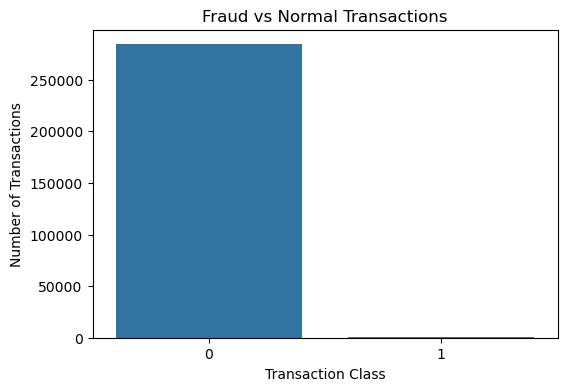

In [7]:
print(df["Class"].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()


In [8]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [11]:
from sklearn.ensemble import IsolationForest

fraud_model = IsolationForest(
    n_estimators=100,
    contamination=0.0017,
    random_state=42,
    n_jobs=-1
)

fraud_model.fit(X_train_scaled)

print("Isolation Forest model trained successfully!")

Isolation Forest model trained successfully!


In [12]:
y_pred_fraud = fraud_model.predict(X_test_scaled)

# Convert Isolation Forest output
y_pred_fraud = np.where(y_pred_fraud == -1, 1, 0)

print("Fraud prediction completed successfully!")
print(y_pred_fraud[:20])

Fraud prediction completed successfully!
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
print("Predicted Normal:", np.sum(y_pred_fraud == 0))
print("Predicted Fraud:", np.sum(y_pred_fraud == 1))

print("\nActual Normal:", np.sum(y_test == 0))
print("Actual Fraud:", np.sum(y_test == 1))

Predicted Normal: 56856
Predicted Fraud: 106

Actual Normal: 56864
Actual Fraud: 98


In [14]:
from sklearn.metrics import classification_report

print("Fraud Detection Classification Report")
print("---------------------------------------")

print(classification_report(
    y_test,
    y_pred_fraud,
    target_names=["Normal", "Fraud"]
))

Fraud Detection Classification Report
---------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



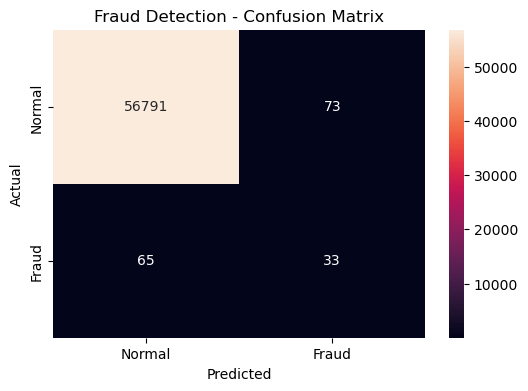

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_fraud)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Detection - Confusion Matrix")
plt.show()

In [16]:
from sklearn.metrics import average_precision_score

fraud_scores = -fraud_model.decision_function(X_test_scaled)

pr_auc = average_precision_score(y_test, fraud_scores)

print("Fraud Detection PR-AUC:", round(pr_auc, 4))

Fraud Detection PR-AUC: 0.218


In [17]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(fraud_model, '../models/fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Fraud detection model and scaler saved successfully!")
print("model: models/fraud_model.pkl")
print("scaler: models/scaler.pkl")

Fraud detection model and scaler saved successfully!
model: models/fraud_model.pkl
scaler: models/scaler.pkl
